In [ ]:
!pip uninstall -y dopamine-rl
!pip uninstall -y kaggle-environments

In [ ]:
!pip install ale-py --upgrade
!pip install gymnasium==0.28.1
!pip install 'stable-baselines3[extra]'
!pip install yfinance pandas
!pip install ta
!pip install PyPortfolioOpt
!pip install wandb
!pip install 'shimmy>=2.0'!pip install git+https://github.com/DLR-RM/stable-baselines3
!pip install gdown

In [1]:
pip install "stable-baselines3==2.7.1a0"

ERROR: Ignored the following yanked versions: 2.2.0, 2.3.0, 2.3.1
ERROR: Could not find a version that satisfies the requirement stable-baselines3==2.7.1a0 (from versions: 0.6.0a1, 0.6.0a5, 0.6.0a8, 0.6.0a10, 0.6.0, 0.7.0a0, 0.7.0a1, 0.7.0, 0.8.0a1, 0.8.0a2, 0.8.0a4, 0.8.0, 0.9.0a2, 0.9.0, 0.10.0a1, 0.10.0, 0.11.0a1, 0.11.0a2, 0.11.0a4, 0.11.0, 0.11.1, 1.0rc0, 1.0rc1, 1.0rc2, 1.0, 1.1.0a3, 1.1.0a6, 1.1.0a7, 1.1.0a11, 1.1.0, 1.2.0, 1.2.1a0, 1.2.1a1, 1.2.1a2, 1.3.0, 1.3.1a3, 1.3.1a4, 1.3.1a7, 1.3.1a8, 1.3.1a9, 1.4.0, 1.4.1a1, 1.5.0, 1.5.1a1, 1.5.1a5, 1.5.1a7, 1.5.1a8, 1.6.0, 1.6.1a2, 1.6.1, 1.6.2, 1.7.0a0, 1.7.0a4, 1.7.0a8, 1.7.0a9, 1.7.0a10, 1.7.0a11, 1.7.0a12, 1.7.0, 1.8.0a2, 1.8.0a8, 1.8.0a9, 1.8.0a10, 1.8.0a13, 1.8.0a14, 1.8.0, 2.0.0a1, 2.0.0a2, 2.0.0a4, 2.0.0a5, 2.0.0a9, 2.0.0a10, 2.0.0a13, 2.0.0, 2.1.0, 2.2.0a8, 2.2.0a9, 2.2.0a11, 2.2.1, 2.3.0a1, 2.3.0a2, 2.3.0a4, 2.3.0a5, 2.3.2, 2.4.0a1, 2.4.0a4, 2.4.0a6, 2.4.0a7, 2.4.0a10, 2.4.0a11, 2.4.0, 2.4.1, 2.5.0a0, 2.5.0a1, 2.5.0, 2.6.0a0,

In [1]:
!pip install git+https://github.com/DLR-RM/stable-baselines3

  Cloning https://github.com/DLR-RM/stable-baselines3 to /tmp/pip-req-build-di4i5u3x
  Running command git clone --filter=blob:none --quiet https://github.com/DLR-RM/stable-baselines3 /tmp/pip-req-build-di4i5u3x
  Resolved https://github.com/DLR-RM/stable-baselines3 to commit 7883ed4d20bc9edf3a22a053c77b3146c518a937
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
pip install git+https://github.com/Stable-Baselines-Team/stable-baselines3-contrib

  Cloning https://github.com/Stable-Baselines-Team/stable-baselines3-contrib to /tmp/pip-req-build-qlys6kgs
  Running command git clone --filter=blob:none --quiet https://github.com/Stable-Baselines-Team/stable-baselines3-contrib /tmp/pip-req-build-qlys6kgs
  Resolved https://github.com/Stable-Baselines-Team/stable-baselines3-contrib to commit 33889dbb215b8992bf463551657b79241f4bccf8
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Note: you may need to restart the kernel to use updated packages.


In [138]:
ls

Article/                             README.md
backend/                             report/
Crawl/                               Results.txt
Data/                                reward_scaling.ipynb
Final_Data/                          reward_scaling_run_3.ipynb
final-ppo-2.ipynb                    reward_scaling_run_4.ipynb
final-ppo.ipynb                      RL/
googlenews_aapl_june2024.json        scholar/
LICENSE                              Sentiment/
multienv.ipynb                       Steps.txt
notebook_rl.ipynb                    validation.ipynb
notebook_weighted_p_action.ipynb     validation_sentiment.py
notebook_weighted_prob_action.ipynb  wandb.ipynb


In [ ]:
from stable_baselines3 import PPO
from sb3_contrib import RecurrentPPO

MODELS = {
    "rppo": RecurrentPPO,
    "ppo": PPO,
}

models = {}

for model_name, ModelClass in MODELS.items():
    path = f"backend/files/{model_name}.zip"
    print(f"Loading {model_name} from {path} ...")
    try:
        models[model_name] = ModelClass.load(path, device="cpu")  # force CPU
        print(f"{model_name} loaded")
    except Exception as e:
        print(f"❌ Failed to load {model_name}: {e}")

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import ta
from ta import add_all_ta_features
from ta.trend import SMAIndicator, EMAIndicator, MACD, CCIIndicator, ADXIndicator
from ta.momentum import RSIIndicator, StochasticOscillator
from ta.volatility import BollingerBands, AverageTrueRange
from ta.volume import OnBalanceVolumeIndicator
from ta.utils import dropna
import itertools
import pandas as pd
import numpy as np

In [3]:
from __future__ import annotations

from typing import List

import gymnasium as gym
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from gymnasium import spaces
from gymnasium.utils import seeding
from stable_baselines3.common.vec_env import DummyVecEnv, SubprocVecEnv

matplotlib.use("Agg")
%matplotlib inline

# from stable_baselines3.common.logger import Logger, KVWriter, CSVOutputFormat

In [5]:
import statistics
import time

import numpy as np
import pandas as pd
from stable_baselines3 import A2C, PPO, DDPG, SAC, TD3
from sb3_contrib import RecurrentPPO, CrossQ, TRPO
from stable_baselines3.common.utils import get_linear_fn
import torch as th
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.callbacks import CallbackList
from stable_baselines3.common.noise import NormalActionNoise
from stable_baselines3.common.noise import OrnsteinUhlenbeckActionNoise
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.logger import configure
# import gdown
import logging
import pandas as pd
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from glob import glob

In [6]:
from pypfopt import expected_returns, risk_models
from pypfopt import EfficientFrontier
from scipy.stats import skew, kurtosis

In [10]:
import wandb
from wandb.integration.sb3 import WandbCallback

In [ ]:
!wandb login --relogin 320a98c6a9ba9e09b5d88d9b64059d763ae265f4

In [7]:
DOW_30_TICKER = [
    "AAPL",
    "BA",
    "GS",
    "JPM",
]

In [8]:
TOTAL_INDICATORS = [
    "ema_20", "ema_60",
    "macd", "macd_signal",
    "rsi_14", "cci_14",
    "atr_14", "boll_width",
    "boll_lb",
    "obv", "vol_sma_20",
    "vix", "vix_rolling_30",
    "ret_1d", "ret_5d", "mom_20d", "zclose_60",
    "rank_mom20", "rank_rsi_mom", "rank_rsi_mr",
    "finbert_future", "fingpt_future",
]

INDICATORS_DOW_30 = [
    # Momentum / Trend
    "mom_20d",       # 20-day momentum
    "ema_20",        # short-term trend
    "ema_60",        # medium-term trend
    "macd",          # MACD
    "macd_signal",   # MACD signal line

    # Overbought / Reversal
    "rsi_14",        # relative strength index

    # Volatility / Risk
    "atr_14",        # average true range
    "boll_width",    # Bollinger band width

    # Price / Returns
    "zclose_60",     # normalized price
    "ret_1d",        # daily return

    # Sentiment / News
    "finbert_future", # NLP-based market sentiment
    "fingpt_future",

    # Optional extras for SAC only
    "obv",           # On-balance volume
]

'\nINDICATORS_DOW_30 = [\n    "mom_20d",        # momentum trend\n    "rsi_14",         # overbought/oversold\n    "boll_width",     # volatility\n    "finbert_future", # sentiment (text-based)\n    "ret_1d",         # short-term price return\n]\n'

In [9]:
lr_schedule = get_linear_fn(3e-4, 5e-5, 1.0)

PPO_PARAMS = {
    "policy": "MlpPolicy",
    "n_steps": 1024,         
    "batch_size": 512,
    "gamma": 0.995,           
    "learning_rate": lr_schedule,    
    "ent_coef": 0.03,        
    "clip_range": 0.2,       
    "n_epochs": 8,
    "gae_lambda": 0.92,
    "max_grad_norm": 0.7,
    "vf_coef": 0.5,
    "target_kl": 0.02,        
}

/home/influx/.conda/envs/finllmrl/lib/python3.13/site-packages/stable_baselines3/common/utils.py:195: UserWarning: get_linear_fn() is deprecated, please use LinearSchedule() instead
  warnings.warn("get_linear_fn() is deprecated, please use LinearSchedule() instead")


In [10]:
lr_schedule = get_linear_fn(1e-4, 5e-6, 1.0)

RECCURENT_PPO_PARAMS = dict(
    policy="MlpLstmPolicy",
    learning_rate=lr_schedule,
    n_steps=1024,
    batch_size=512,
    gamma=0.995,
    ent_coef=0.015,
    clip_range=0.2,
    clip_range_vf=0.2,
    n_epochs=8,
    gae_lambda=0.95,
    max_grad_norm=0.5,
    vf_coef=0.5,
    target_kl=0.02,
)

In [11]:
DEFAULT_PARAMS = {
    "ppo": PPO_PARAMS,
    "rppo": RECCURENT_PPO_PARAMS,
}

DEFAULT_PARAMS_POLICY = {
    "ppo": {
        'net_arch': dict(pi=[128, 192], vf=[128, 192])
    },
    "rppo": dict(
        net_arch=[128, 192],
        lstm_hidden_size=128,
        n_lstm_layers=1,
        shared_lstm=False,
        ortho_init=False,
    )
}

In [12]:
MODELS = {"sac": SAC, "ppo": PPO, "rppo": RecurrentPPO}

In [13]:
NOISE = {
    "normal": NormalActionNoise,
    "ornstein_uhlenbeck": OrnsteinUhlenbeckActionNoise,
}

In [14]:
TRAIN_START_DATE = '2010-01-01'
TRAIN_END_DATE = '2022-12-31'

VALID_START_DATE = '2023-01-01'
VALID_END_DATE = '2023-12-31'

TRADE_START_DATE= '2024-01-01'
TRADE_END_DATE = '2025-08-31'

In [15]:
# Algorithms to run
ALGORITHMS = ["ppo", "rppo"]

In [16]:
TOT_TIMESTEPS = {
    "ppo": {
        1: 600_000,
        4: 2_000_000
    },
    "rppo": {
        1: 600_000,
        4: 2_000_000
    }
}

In [17]:
params = {
    "ind_train": INDICATORS_DOW_30,
    "hmax_train": 100,
    "initial_amount_train": 1_000_000,
    "reward_scaling_train": 10.0,
    "hmax_test": 100,
    "initial_amount_test": 1_000_000,
    "reward_scaling_test": 10.0,
}

In [18]:
def _adjust_prices(data_df: pd.DataFrame) -> pd.DataFrame:
    # use adjusted close price instead of close price
    data_df["adj"] = data_df["adjcp"] / data_df["close"]
    for col in ["open", "high", "low", "close"]:
        data_df[col] *= data_df["adj"]

    # drop the adjusted close price column
    return data_df.drop(["adjcp", "adj"], axis=1)

In [19]:
def get_data(dataset, start_date, end_date):
    if dataset == "DOW_30":
        """Fetches data from Yahoo API
        Returns
        -------
        `pd.DataFrame`
            7 columns: A date, open, high, low, close, volume and tick symbol
            for the specified stock ticker
        """
        # Download and save the data in a pandas DataFrame:
        data_df = pd.DataFrame()
        num_failures = 0
        for tic in DOW_30_TICKER:
            temp_df = yf.download(
                tic,
                start=start_date,
                end=end_date,
                auto_adjust=False,
            )
            if temp_df.columns.nlevels != 1:
                temp_df.columns = temp_df.columns.droplevel(1)
            temp_df["tic"] = tic
            if len(temp_df) > 0:
                data_df = pd.concat([data_df, temp_df], axis=0)
            else:
                num_failures += 1

        if num_failures == len(DOW_30_TICKER):
            raise ValueError("no data is fetched.")

        # reset the index, we want to use numbers as index instead of dates
        data_df = data_df.reset_index()
        try:
            # convert the column names to standardized names
            data_df.rename(
                columns={
                    "Date": "date",
                    "Adj Close": "adjcp",
                    "Close": "close",
                    "High": "high",
                    "Low": "low",
                    "Volume": "volume",
                    "Open": "open",
                    "tic": "tic",
                },
                inplace=True,
            )

            data_df = _adjust_prices(data_df)
        except NotImplementedError:
            print("the features are not supported currently")

        # create day of the week column (monday = 0)
        data_df["day"] = data_df["date"].dt.dayofweek

        # drop missing data
        data_df = data_df.dropna()
        data_df = data_df.reset_index(drop=True)

        print("Shape of DataFrame: ", data_df.shape)
        # print("Display DataFrame: ", data_df.head())

        data_df = data_df.sort_values(by=["date", "tic"]).reset_index(drop=True)

        return data_df
    elif dataset == "XAU-G/USD":
        pass
    elif dataset == "Crypto":
        pass

In [20]:
def clean_data(data):
    df = data.copy()
    df = df.sort_values(["date", "tic"], ignore_index=True)
    df.index = df.date.factorize()[0]
    merged_closes = df.pivot_table(index="date", columns="tic", values="close")
    merged_closes = merged_closes.dropna(axis=1)
    tics = merged_closes.columns
    df = df[df.tic.isin(tics)]
    return df

In [21]:
def add_indicators(df, dataset):
    df = df.sort_values(['tic', 'date']).reset_index(drop=True)

    if dataset == "DOW_30":
        df_indicators = pd.DataFrame()

        for tic, group in df.groupby('tic'):
            group = group.copy()

            # --- Trend indicators ---
            group['ema_20'] = EMAIndicator(group['close'], window=20).ema_indicator()
            group['ema_60'] = EMAIndicator(group['close'], window=60).ema_indicator()
            macd = MACD(group['close'])
            group['macd'] = macd.macd()
            group['macd_signal'] = macd.macd_signal()

            # --- Momentum indicators ---
            group['rsi_14'] = RSIIndicator(group['close'], window=14).rsi()
            group['cci_14'] = CCIIndicator(group['high'], group['low'], group['close'], window=14).cci()

            # --- Volatility indicators ---
            boll = BollingerBands(close=group['close'], window=20, window_dev=2)
            group['boll_ub'] = boll.bollinger_hband()
            group['boll_lb'] = boll.bollinger_lband()
            group['boll_width'] = group['boll_ub'] - group['boll_lb']
            group['atr_14'] = AverageTrueRange(group['high'], group['low'], group['close'], window=14).average_true_range()

            # --- Volume indicators ---
            group['obv'] = OnBalanceVolumeIndicator(group['close'], group['volume']).on_balance_volume()
            group['vol_sma_20'] = group['volume'].rolling(window=20).mean()

            # --- Price-based features ---
            group['ret_1d']  = group['close'].pct_change(1)
            group['ret_5d']  = group['close'].pct_change(5)
            group['mom_20d'] = group['close'].pct_change(20)

            roll_mean = group['close'].rolling(60).mean()
            roll_std  = group['close'].rolling(60).std()
            group['zclose_60'] = (group['close'] - roll_mean) / (roll_std + 1e-8)

            df_indicators = pd.concat([df_indicators, group], axis=0)

        # --- Final sorting and cleanup ---
        df_indicators = df_indicators.replace([np.inf, -np.inf], np.nan).dropna()
        df_indicators = df_indicators.sort_values(['tic', 'date']).reset_index(drop=True)

        # --- Cross-sectional ranks ---
        by_date = df_indicators.groupby('date')
        df_indicators['rank_mom20']    = by_date['mom_20d'].rank(pct=True, method='first')
        df_indicators['rank_rsi_mom']  = by_date['rsi_14'].rank(pct=True, method='first')
        df_indicators['rank_rsi_mr']   = 1.0 - df_indicators['rank_rsi_mom']

        # --- Ensure all INDICATORS_DOW_30 columns exist ---
        for col in INDICATORS_DOW_30:
            if col not in df_indicators.columns:
                df_indicators[col] = np.nan

        # --- Drop columns not in original + INDICATORS_DOW_30 ---
        original_cols = [c for c in df.columns]  # keep original columns
        print(original_cols)
        cols_to_keep = original_cols + INDICATORS_DOW_30
        df_indicators = df_indicators[cols_to_keep]

        return df_indicators

    elif dataset == "XAU-G/USD":
        pass
    elif dataset == "Crypto":
        pass


In [22]:
def add_vix(data):
    """
    Add VIX data from Yahoo Finance using yfinance.

    :param data: (pd.DataFrame) Must have a 'date' column (datetime or string).
    :return: (pd.DataFrame) Original dataframe with 'vix' column added.
    """
    df = data.copy()

    # Ensure 'date' is datetime
    df["date"] = pd.to_datetime(df["date"])

    # Download VIX data
    vix_df = yf.download(
        "^VIX",
        start=df["date"].min().strftime("%Y-%m-%d"),
        end=(df["date"].max() + pd.Timedelta(days=1)).strftime("%Y-%m-%d"),
        progress=False
    )

    # Reset index to get 'Date' as a column
    vix_df = vix_df.reset_index()[["Date", "Close"]]
    vix_df.columns = ["date", "vix"]

    # Merge with original dataframe
    df = df.merge(vix_df, on="date", how="left")

    # Sort
    df = df.sort_values(["date", "tic"]).reset_index(drop=True)

    return df

In [23]:
def calculate_turbulence(data):
    """calculate turbulence index based on dow 30"""
    # can add other market assets
    df = data.copy()
    df_price_pivot = df.pivot(index="date", columns="tic", values="close")

    # use returns to calculate turbulence
    df_price_pivot = df_price_pivot.pct_change()

    unique_date = df.date.unique()
    # start after a year
    start = 252
    turbulence_index = [0] * start
    # turbulence_index = [0]
    count = 0
    for i in range(start, len(unique_date)):
        current_price = df_price_pivot[df_price_pivot.index == unique_date[i]]
        # use one year rolling window to calcualte covariance
        hist_price = df_price_pivot[
            (df_price_pivot.index < unique_date[i])
            & (df_price_pivot.index >= unique_date[i - 252])
        ]
        # Drop tickers which has number missing values more than the "oldest" ticker
        filtered_hist_price = hist_price.iloc[
            hist_price.isna().sum().min() :
        ].dropna(axis=1)

        cov_temp = filtered_hist_price.cov()
        current_temp = current_price[[x for x in filtered_hist_price]] - np.mean(
            filtered_hist_price, axis=0
        )
        # cov_temp = hist_price.cov()
        # current_temp=(current_price - np.mean(hist_price,axis=0))

        temp = current_temp.values.dot(np.linalg.pinv(cov_temp)).dot(
            current_temp.values.T
        )
        if temp > 0:
            count += 1
            if count > 2:
                turbulence_temp = temp[0][0]
            else:
                # avoid large outlier because of the calculation just begins
                turbulence_temp = 0
        else:
            turbulence_temp = 0
        turbulence_index.append(turbulence_temp)
    try:
        turbulence_index = pd.DataFrame(
            {"date": df_price_pivot.index, "turbulence": turbulence_index}
        )
    except ValueError:
        raise Exception("Turbulence information could not be added.")
    return turbulence_index

In [24]:
def add_turbulence(data):
    """
    add turbulence index from a precalcualted dataframe
    :param data: (df) pandas dataframe
    :return: (df) pandas dataframe
    """
    df = data.copy()
    turbulence_index = calculate_turbulence(df)
    df = df.merge(turbulence_index, on="date")
    df = df.sort_values(["date", "tic"]).reset_index(drop=True)
    return df

In [25]:
def data_split(df, start, end, target_date_col="date"):
    """
    split the dataset into training or testing using date
    :param data: (df) pandas dataframe, start, end
    :return: (df) pandas dataframe
    """
    data = df[(df[target_date_col] >= start) & (df[target_date_col] < end)]
    data = data.sort_values([target_date_col, "tic"], ignore_index=True)
    data.index = data[target_date_col].factorize()[0]
    return data

In [26]:
class StockTradingEnv(gym.Env):
    """
    A stock trading environment for OpenAI gym

    Parameters:
        df (pandas.DataFrame): Dataframe containing data
        hmax (int): Maximum cash to be traded in each trade per asset.
        initial_amount (int): Amount of cash initially available
        buy_cost_pct (float, array): Cost for buying shares, each index corresponds to each asset
        sell_cost_pct (float, array): Cost for selling shares, each index corresponds to each asset
        turbulence_threshold (float): Maximum turbulence allowed in market for purchases to occur.
                                      If exceeded, positions are liquidated
        print_verbosity(int): When iterating (step), how often to print stats about state of env
    """

    metadata = {"render.modes": ["human"]}

    def __init__(
        self,
        df: pd.DataFrame,
        stock_dim: int,
        hmax: int,
        initial_amount: int,
        num_stock_shares: list[int],
        buy_cost_pct: list[float],
        sell_cost_pct: list[float],
        reward_scaling: float,
        state_space: int,
        action_space: int,
        tech_indicator_list: list[str],
        turbulence_hard_threshold=None,
        turbulence_soft_threshold=None,
        risk_indicator_col="turbulence",
        make_plots: bool = False,
        print_verbosity=1,
        day=0,
        initial=True,
        previous_state=[],
        model_name="",
        mode="",
        iteration="",
        log_verbose: bool = True,  # NEW FLAG
        randomize_episodes: bool = True
    ):
        # ---------------------------
        # 📝 Logger setup
        # ---------------------------
        import logging
        import os

        log_file_path = "/kaggle/working/" + "trading_env.log"

        self.logger = logging.getLogger("StockTradingEnv")
        self.logger.setLevel(logging.DEBUG if log_verbose else logging.CRITICAL)

        # Prevent printing to console
        self.logger.propagate = False

        if not self.logger.handlers:  # avoid duplicate handlers
            # File handler (append mode to keep history)
            fh = logging.FileHandler(log_file_path, mode="a")
            fh.setLevel(logging.DEBUG if log_verbose else logging.CRITICAL)

            formatter = logging.Formatter(
                "%(asctime)s - %(levelname)s - %(message)s",
                datefmt="%Y-%m-%d %H:%M:%S"
            )
            fh.setFormatter(formatter)
            self.logger.addHandler(fh)

        self.logger.info("\n[INIT] ===== StockTradingEnv =====")

        # ---------------------------
        # 🔧 Core attributes (as before)
        # ---------------------------
        self.day = day
        self.sday = day
        self.df = df
        self.stock_dim = stock_dim
        self.hmax = hmax
        self.init_num_stock_shares = num_stock_shares.copy()
        self.num_stock_shares = num_stock_shares.copy()
        self.initial_amount = initial_amount
        self.cash = initial_amount
        self.buy_cost_pct = buy_cost_pct
        self.sell_cost_pct = sell_cost_pct
        self.reward_scaling = reward_scaling
        self.state_space = state_space
        self.action_space = action_space
        self.tech_indicator_list = tech_indicator_list

        # ---------------------------
        # 🧪 Dataset sanity logs
        # ---------------------------
        try:
            head_idx = self.df.index[:5].tolist()
        except Exception:
            head_idx = str(self.df.index)[:80]

        if "date" in self.df.columns:
            self.n_days = len(self.df["date"].unique())
        else:
            self.n_days = len(self.df.index.unique())

        # --- episode randomization knobsself.sday ---
        self.randomize_episodes = randomize_episodes      # turn on/off
        self.min_episode_len = 1500          # at least this many steps
        self.episode_end_day = self.n_days  # will be set at reset

        if "tic" in self.df.columns:
            n_tics = int(self.df["tic"].nunique())
        # ---------------------------
        # 🎯 Spaces
        # ---------------------------
        self.action_dim = self.action_space + 1
        self.action_space = spaces.Box(low=-1, high=1, shape=(self.action_dim,))
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(self.state_space,))

        # ---------------------------
        # 📅 Initial day slice
        # ---------------------------
        self.data = self.df.loc[self.day, :]
        try:
            first_date = (self.data["date"].iloc[0]
                          if hasattr(self.data["date"], "iloc")
                          else self.data["date"])
        except Exception:
            first_date = "<?>"

        
        # ---------------------------
        # ✅ Thresholds (turbulence)
        # ---------------------------
        self.terminal = False
        self.make_plots = make_plots
        self.print_verbosity = print_verbosity
        self.risk_indicator_col = risk_indicator_col

        if turbulence_soft_threshold is None or turbulence_hard_threshold is None:
            if self.risk_indicator_col in self.df.columns:
                values = self.df[self.risk_indicator_col].values
                q95 = np.nanpercentile(values, 95)
                q995 = np.nanpercentile(values, 99.5)
                self.turbulence_soft_threshold = (turbulence_soft_threshold if turbulence_soft_threshold else q95)
                self.turbulence_hard_threshold = (turbulence_hard_threshold if turbulence_hard_threshold else q995)
            else:
                self.turbulence_soft_threshold = turbulence_soft_threshold
                self.turbulence_hard_threshold = turbulence_hard_threshold
        else:
            self.turbulence_soft_threshold = turbulence_soft_threshold
            self.turbulence_hard_threshold = turbulence_hard_threshold

        self.turbulence_soft_threshold = 70
        self.turbulence_hard_threshold = 100
        
        # ---------------------------
        # 🔁 Previous state bookkeeping
        # ---------------------------
        self.initial = initial
        self.previous_state = previous_state
        self.previous_cash = initial_amount
        self.previous_num_stock_shares = num_stock_shares.copy()
        self.model_name = model_name
        self.mode = mode
        self.iteration = iteration

        # ---------------------------
        # 🧮 Build initial state
        # ---------------------------
        self.state = self._initiate_state()
        state_len = len(self.state) if hasattr(self.state, "__len__") else None

        # ---------------------------
        # 📈 Memories & counters
        # ---------------------------
        self.return_log = []
        self.vol_log = []

        self.reward = 0
        self.turbulence = 0
        self.cost = 0
        self.trades = 0
        self.episode = 0
        self.step_cost = 0

        try:
            prices = self.data["close"].values

        except Exception as e:
            prices = np.zeros(self.stock_dim, dtype=float)

        self.asset_memory = [
            self.initial_amount + np.sum(np.array(self.num_stock_shares) * prices)
        ]

        # Sanity checks for list lengths
        def _check_len(name, arr, target):
            try:
                ln = len(arr)
            except Exception:
                ln = None
            ok = (ln == target)
            return ok

        _check_len("num_stock_shares", self.num_stock_shares, self.stock_dim)
        _check_len("buy_cost_pct", self.buy_cost_pct, self.stock_dim)
        _check_len("sell_cost_pct", self.sell_cost_pct, self.stock_dim)

        self.rewards_memory = []
        self.actions_memory = []
        self.state_memory = []
        self.date_memory = [self._get_date()]

        self._seed()

    def _sell_stock(self, index, action):
        # action is negative: number of shares to sell
        to_sell = int(min(abs(int(action)), int(self.num_stock_shares[index])))
        if to_sell <= 0:
            return 0
            
        price = float(self.data['close'].values[index])
        fee = float(self.sell_cost_pct[index])
        proceeds = price * to_sell * (1.0 - fee)
        
        self.cash += proceeds
        self.num_stock_shares[index] -= to_sell
        
        self.cost += price * to_sell * fee
        self.step_cost += price * to_sell * fee
        
        self.trades += 1
        
        return to_sell
    
    def _buy_stock(self, index, action):
        to_buy_req = max(0, int(action))
        
        if to_buy_req <= 0:
            return 0
            
        price = float(self.data['close'].values[index])
        fee = float(self.buy_cost_pct[index])
        cps = price * (1.0 + fee)
        max_afford = int(self.cash // max(cps, 1e-12))
        to_buy = min(to_buy_req, max_afford)
        if to_buy <= 0:
            return 0
            
        spend = cps * to_buy
        self.cash -= spend
        
        self.num_stock_shares[index] += to_buy
        self.cost += price * to_buy * fee
        self.step_cost += price * to_buy * fee
        self.trades += 1
        return to_buy

    def _make_plot(self):
        plt.plot(self.asset_memory, "r")
        plt.savefig(f"results/account_value_trade_{self.episode}.png")
        plt.close()

    def step(self, actions):
        if self.day >= self.episode_end_day - 1:
            self.terminal = True

        if self.terminal:
            if self.make_plots:
                self._make_plot()

            current_prices = self.data['close'].values
            end_total_asset = self.cash + sum(np.array(self.num_stock_shares) * current_prices)

            df_total_value = pd.DataFrame(self.asset_memory, columns=["account_value"])
            df_total_value["date"] = self.date_memory
            df_total_value["daily_return"] = df_total_value["account_value"].pct_change(1)

            tot_reward = end_total_asset - self.asset_memory[0]

            sharpe = None
            if df_total_value["daily_return"].std() != 0:
                sharpe = (252 ** 0.5) * df_total_value["daily_return"].mean() / df_total_value["daily_return"].std()

            df_rewards = pd.DataFrame(self.rewards_memory, columns=["account_rewards"])
            df_rewards["date"] = self.date_memory[:-1]

            print(f"[SUMMARY] Begin total asset: {self.asset_memory[0]:.2f}")
            print(f"[SUMMARY] End total asset: {end_total_asset:.2f}")
            print(f"[SUMMARY] Total reward: {tot_reward:.2f}")
            print(f"[SUMMARY] Total cost: {self.cost:.2f}")
            print(f"[SUMMARY] Total trades: {self.trades}")
            if sharpe is not None:
                print(f"[SUMMARY] Sharpe ratio: {sharpe:.3f}")
            print(f"[SUMMARY] Final shares per stock: {self.num_stock_shares}")
            print("=================================")

            results_dir = os.path.join("/kaggle/working/", "results")
            os.makedirs(results_dir, exist_ok=True)

            if (self.model_name != "") and (self.mode != ""):
                df_actions = self.save_action_memory()
                df_actions.to_csv(
                    os.path.join(results_dir, f"actions_{self.mode}_{self.model_name}_{self.iteration}.csv"),
                    index=False,
                )
                df_total_value.to_csv(
                    os.path.join(results_dir, f"account_value_{self.mode}_{self.model_name}_{self.iteration}.csv"),
                    index=False,
                )
                df_rewards.to_csv(
                    os.path.join(results_dir, f"account_rewards_{self.mode}_{self.model_name}_{self.iteration}.csv"),
                    index=False,
                )

                plt.plot(self.asset_memory, "r")
                plt.title(f"Account Value - Episode {self.episode}")
                plt.xlabel("Step")
                plt.ylabel("Total Asset")
                plt.savefig(
                    os.path.join(results_dir, f"account_value_{self.mode}_{self.model_name}_{self.iteration}.png")
                )
                plt.close()

            return self.state, self.reward, self.terminal, False, {}

        else:
            begin_prices = self.data['close'].values
            begin_total_asset = self.cash + sum(np.array(self.num_stock_shares) * begin_prices)

            logits = actions.astype(float)
            shift = logits.max()
            exp = np.exp(logits - shift)
            w_all = exp / (exp.sum() + 1e-12)
            
            w_stocks = w_all[:-1]

            cap = 0.50
            w_stocks = np.minimum(w_stocks, cap)
            stock_sum = w_stocks.sum()
            
            target_dollars = w_stocks * begin_total_asset
            target_shares  = np.floor(target_dollars / begin_prices).astype(int)

            current_shares = np.array(self.num_stock_shares, dtype=int)
            delta = target_shares - current_shares  # +ve = buy, -ve = sell

            sell_index = np.flatnonzero(delta < 0)
            buy_index  = np.flatnonzero(delta > 0)

            self.previous_cash = self.cash
            self.previous_state = self.state.copy()
            self.previous_num_stock_shares = self.num_stock_shares.copy()

            executed = np.zeros(self.stock_dim, dtype=int)

            hard_turb = self.turbulence_hard_threshold is not None and self.turbulence >= self.turbulence_hard_threshold
            soft_turb = (self.turbulence_soft_threshold is not None) and (self.turbulence >= self.turbulence_soft_threshold)

            for idx in range(self.stock_dim):
                if hard_turb:
                    if self.num_stock_shares[idx] > 0:
                        sold = self._sell_stock(idx, -self.num_stock_shares[idx])
                        executed[idx] -= int(sold)
                else:
                    if delta[idx] < 0:
                        sold = self._sell_stock(idx, delta[idx])
                        executed[idx] -= int(sold)

            if not hard_turb and not soft_turb:
                desired = np.zeros(self.stock_dim, dtype=int)
                desired[buy_index] = delta[buy_index]
            
                if buy_index.size > 0:
                    cps = begin_prices[buy_index] * (1.0 + self.buy_cost_pct[buy_index])
                    max_afford = np.floor(self.cash / np.maximum(cps, 1e-12)).astype(int)
            
                    desired_cost = (desired[buy_index] * cps).sum()
                    if desired_cost > self.cash + 1e-9:
                        scale = float(self.cash / desired_cost)
                        scaled = np.floor(desired[buy_index] * scale).astype(int)
                    else:
                        scaled = desired[buy_index]
            
                    scaled = np.maximum(0, np.minimum(scaled, max_afford))
            
                    for i, idx in enumerate(buy_index):
                        if scaled[i] > 0:
                            bought = self._buy_stock(idx, int(scaled[i]))  # positive
                            executed[idx] += int(bought)

            self.actions_memory.append(executed)

            # update day and state
            self.day += 1
            self.data = self.df.loc[self.day, :]
            if self.risk_indicator_col is not None:
                if len(self.df.tic.unique()) == 1:
                    self.turbulence = self.data[self.risk_indicator_col]
                else:
                    self.turbulence = self.data[self.risk_indicator_col].values[0]

            self.state = self._update_state()

            # Compute end total asset
            current_prices = self.data['close'].values
            end_total_asset = self.cash + sum(np.array(self.num_stock_shares) * current_prices)
            self.asset_memory.append(end_total_asset)
            self.date_memory.append(self._get_date())

            # --- Reward hyperparameters ---
            alpha = 1.0    # weight for return
            
            # --- Portfolio log return ---
            return_val = (end_total_asset - begin_total_asset) / (begin_total_asset + 1e-8)
            return_val *= self.reward_scaling
            return_val *= self.n_days
            return_val /= (self.episode_end_day - self.sday + 1)
            self.reward = return_val * self.reward_scaling

            # --- Logging ---
            self.logger.info(
                f"[STEP] End asset: {end_total_asset:.2f}, "
                f"Reward: {self.reward:.6f}, "
            )
                        
            # Logging
            self.return_log.append(return_val)
            
            self.rewards_memory.append(self.reward)
            self.state_memory.append(self.state)

            self.step_cost = 0

            return self.state, self.reward, self.terminal, False, {}

    def reset(
        self,
        *,
        seed=None,
        options=None,
    ):

        total = self.n_days

        if self.randomize_episodes:
            choice = int(self.np_random.integers(1, 4))  # random integer between 1 and 3 inclusive
        
            if choice == 2:
                self.sday = 0
                self.day = 0
                self.episode_end_day = total
            else:
                start_hi = total - self.min_episode_len
                start_day = int(self.np_random.integers(0, start_hi))
        
                max_len_allowed = total - start_day
                ep_len = int(self.np_random.integers(self.min_episode_len, max_len_allowed + 1))

                self.sday = start_day
                self.day = start_day
                self.episode_end_day = min(self.day + ep_len, total)
        else:
            self.sday = 0
            self.day = 0
            self.episode_end_day = total

        # Reset day and data
        self.data = self.df.loc[self.day, :]

        # Reset state and shares
        self.state = self._initiate_state()
        self.num_stock_shares = self.init_num_stock_shares.copy()
        self.cash = self.initial_amount

        # Get initial prices and calculate initial total asset
        initial_prices = self.data['close'].values
        initial_total_asset = self.initial_amount + np.sum(np.array(self.num_stock_shares) * initial_prices)
        self.asset_memory = [initial_total_asset]

        # Reset accounting variables
        self.cost = 0
        self.step_cost = 0
        self.trades = 0
        self.terminal = False
        self.rewards_memory = []
        self.actions_memory = []
        self.date_memory = [self._get_date()]

        # Increment episode count
        self.episode += 1

        return self.state, {}


    def render(self, mode="human", close=False):
        # Simple render: return current state
        return self.state


    def _initiate_state(self):
        self.cash = self.initial_amount
        self.num_stock_shares = self.init_num_stock_shares.copy()

        current_prices = self.data['close'].values
        total_asset = self.cash + np.sum(np.array(self.num_stock_shares) * current_prices)
        norm_cash = self.cash / (total_asset + 1e-8)
        norm_shares = [shares / (self.hmax + 1e-8) for shares in self.num_stock_shares]
        vix_value = self.data["vix"].values[0]
        
        state = (
            [norm_cash]
            + norm_shares
            + sum(
                (self.data[tech].values.tolist() for tech in self.tech_indicator_list),
                [],
            ) + [vix_value]
        )

        return state


    def _update_state(self):
        current_prices = self.data['close'].values
        total_asset = self.cash + np.sum(np.array(self.num_stock_shares) * current_prices)
        norm_cash = self.cash / (total_asset + 1e-8)
        norm_shares = [shares / (self.hmax + 1e-8) for shares in self.num_stock_shares]
        vix_value = self.data["vix"].values[0]

        state = (
            [norm_cash]
            + norm_shares
            + sum(
                (self.data[tech].values.tolist() for tech in self.tech_indicator_list),
                [],
            ) + [vix_value]
        )

        return state

    def _get_date(self):
        if len(self.df.tic.unique()) > 1:
            date = self.data.date.unique()[0]
        else:
            date = self.data.date
        return date


    def save_asset_memory(self):
        date_list = self.date_memory
        asset_list = self.asset_memory

        df_account_value = pd.DataFrame(
            {"date": date_list, "account_value": asset_list}
        )
        return df_account_value


    def save_action_memory(self):
        # date and close price length must match actions length
        date_list = self.date_memory[:-1]
        df_date = pd.DataFrame(date_list)
        df_date.columns = ["date"]

        action_list = self.actions_memory
        df_actions = pd.DataFrame(action_list)
        df_actions.columns = self.data.tic.values
        df_actions.index = df_date['date']

        return df_actions


    def _seed(self, seed=None):
        self.np_random, seed = seeding.np_random(seed)
        return [seed]


    def get_sb_env(self):
        e = DummyVecEnv([lambda: self])
        obs = e.reset()
        return e, obs

In [27]:
class TensorboardCallback(BaseCallback):
    """
    TensorBoard logging callback for SB3 models.
    Logs rewards, episode lengths, rollout stats, actions, and learning rates.
    """

    def __init__(self, verbose=0, track_actions=True):
        super().__init__(verbose)
        self.episode_rewards = []
        self.episode_lengths = []
        self.current_episode_reward = 0
        self.current_episode_length = 0
        self.start_time = None
        self.track_actions = track_actions
        self.actions_buffer = []

    def _on_training_start(self) -> None:
        self.start_time = time.time()
        self.logger.record("time/training_start", self.start_time)
        if self.verbose:
            print(f"[TB] Training started at {self.start_time}")
    
    def _on_step(self) -> bool:
        try:
            reward = None
            if "rewards" in self.locals:   # SB3 VecEnv case
                reward = self.locals["rewards"]
            elif "reward" in self.locals:  # single env case
                reward = self.locals["reward"]
    
            if reward is not None:
                if isinstance(reward, (list, np.ndarray)):
                    reward_vals = np.array(reward).flatten()
                    reward_val = float(np.mean(reward_vals))   # average across envs
                else:
                    reward_val = float(reward)
    
                self.current_episode_reward += reward_val
                self.current_episode_length += 1
                self.logger.record("train/step_reward", reward_val)
    
            if self.track_actions and "actions" in self.locals:
                act = self.locals["actions"]
                if isinstance(act, (list, np.ndarray)):
                    self.actions_buffer.append(np.array(act).flatten())
                else:
                    self.actions_buffer.append([act])
    
        except Exception as e:
            if self.verbose:
                print(f"[TB Warning] Step logging error: {e}")
    
        # Handle dones (can also be an array in multi-envs)
        done = None
        if "dones" in self.locals:
            done = np.any(self.locals["dones"])  # at least one env is done
        elif "done" in self.locals:
            done = bool(self.locals["done"])
    
        if done:
            self.episode_rewards.append(self.current_episode_reward)
            self.episode_lengths.append(self.current_episode_length)
    
            self.logger.record("train/episode_reward", self.current_episode_reward)
            self.logger.record("train/episode_length", self.current_episode_length)
    
            if len(self.episode_rewards) >= 5:
                self.logger.record(
                    "train/episode_reward_mean_5", np.mean(self.episode_rewards[-5:])
                )
    
            if self.verbose:
                print(
                    f"[TB] Episode done. Reward: {self.current_episode_reward:.2f}, "
                    f"Length: {self.current_episode_length}"
                )
    
            self.current_episode_reward = 0
            self.current_episode_length = 0
            self.actions_buffer.clear()
    
        return True

    def _on_rollout_end(self) -> None:
        try:
            rb_rewards = self.locals["rollout_buffer"].rewards.flatten()
            self.logger.record("train/rollout_reward_min", float(np.min(rb_rewards)))
            self.logger.record("train/rollout_reward_mean", float(np.mean(rb_rewards)))
            self.logger.record("train/rollout_reward_max", float(np.max(rb_rewards)))
        except Exception:
            pass

        if self.track_actions and len(self.actions_buffer) > 0:
            acts = np.concatenate(self.actions_buffer)
            self.logger.record("actions/mean", float(np.mean(acts)))
            self.logger.record("actions/std", float(np.std(acts)))
            self.logger.record("actions/min", float(np.min(acts)))
            self.logger.record("actions/max", float(np.max(acts)))

        try:
            if hasattr(self.model, "lr_schedule"):
                lr = self.model.lr_schedule(self.model._current_progress_remaining)
            elif hasattr(self.model, "learning_rate"):
                lr = self.model.learning_rate
            else:
                lr = None
            if lr is not None:
                self.logger.record("train/learning_rate", float(lr))
        except Exception:
            pass

    def _on_training_end(self) -> None:
        total_time = time.time() - self.start_time
        self.logger.record("time/training_end", time.time())
        self.logger.record("time/total_training_time_sec", total_time)
        if self.verbose:
            print(f"[TB] Training finished in {total_time:.2f} seconds.")

In [28]:
class DRLAgent:
    """DRL agent helper for SB3 algorithms"""

    def __init__(self, env):
        self.env = env

    def get_model(
        self,
        model_name,
        policy_kwargs=None,
        model_kwargs=None,
        verbose=1,
        seed=None,
        tensorboard_log=None,
    ):
        if model_name not in MODELS:
            raise ValueError(f"Model '{model_name}' not found in MODELS.")

        model_kwargs = DEFAULT_PARAMS[model_name]
        policy_kwargs = DEFAULT_PARAMS_POLICY[model_name]
        
        if "action_noise" in model_kwargs:
            n_actions = self.env.action_space.shape[-1]
            model_kwargs["action_noise"] = NOISE[model_kwargs["action_noise"]](
                mean=np.zeros(n_actions), sigma=0.1 * np.ones(n_actions)
            )

        if verbose:
            print(f"[DRLAgent] Initializing model {model_name} with kwargs: {model_kwargs}")

        return MODELS[model_name](
            env=self.env,
            tensorboard_log=tensorboard_log,
            verbose=verbose,
            policy_kwargs=policy_kwargs,
            seed=seed,
            **model_kwargs,
        )

    @staticmethod
    def train_model(model, tb_log_name, total_timesteps=5000, callbacks: Optional[list] = None):
        all_callbacks = [TensorboardCallback(verbose=1)]
        if callbacks:
            all_callbacks += callbacks

        print(f"[DRLAgent] Starting training for {total_timesteps} timesteps...")
        model = model.learn(
            total_timesteps=total_timesteps,
            tb_log_name=tb_log_name,
            callback=CallbackList(all_callbacks),
        )
        print(f"[DRLAgent] Training finished.")
        return model

    @staticmethod
    def DRL_prediction(model, environment, deterministic=True):
        """Make predictions and return account memory and actions memory"""
        test_env, test_obs = environment.get_sb_env()
        account_memory = None
        actions_memory = None
        test_env.reset()
        max_steps = len(environment.df.index.unique()) - 1

        for i in range(len(environment.df.index.unique())):
            action, _states = model.predict(test_obs, deterministic=deterministic)
            test_obs, rewards, dones, info = test_env.step(action)

            if i == max_steps - 1:
                account_memory = test_env.env_method("save_asset_memory")
                actions_memory = test_env.env_method("save_action_memory")

            if dones[0]:
                print(f"[DRLAgent] Hit end of environment at step {i}")
                break

        print("[DRLAgent] Prediction finished.")
        return account_memory[0], actions_memory[0]


In [29]:
def build_mvo_and_baselines(train_df, trade_price_df, initial_capital=1_000_000, weight_bounds=(0,0.5)):
    """
    train_df: raw rows with columns ['date','tic','close'] used to compute mu/cov
    trade_price_df: pivoted index=date, columns=tic with prices (out-of-sample period)
    """
    price_train = train_df.pivot(index='date', columns='tic', values='close').sort_index()
    price_train.index = pd.to_datetime(price_train.index)
    # compute daily returns
    returns_train = price_train.pct_change().dropna()

    # try pypfopt
    try:
        mu = expected_returns.mean_historical_return(price_train)  # annualized mu
        S = risk_models.sample_cov(price_train)
        ef = EfficientFrontier(mu, S, weight_bounds=weight_bounds)
        ef.max_sharpe()
        weights = ef.clean_weights()
        print("MVO weights from PyPortfolioOpt")
    except Exception as e:
        print("pypfopt not available or failed:", e)
        # fallback to equal weight
        cols = price_train.columns.tolist()
        weights = {c: 1/len(cols) for c in cols}
        print("Using equal-weight fallback")

    # prepare weights aligned with trade_price_df columns
    w_arr = np.array([weights.get(t, 0.0) for t in trade_price_df.columns])

    # compute shares from last available price in trade_price_df
    last_prices = trade_price_df.iloc[-1].to_numpy()
    dollar_alloc = w_arr * initial_capital
    # avoid divide by zero
    shares = np.where(last_prices > 0, dollar_alloc / last_prices, 0.0)

    # portfolio value time series
    portfolio_values = (trade_price_df.values * shares).sum(axis=1)
    df_mvo = pd.DataFrame({'date': trade_price_df.index, 'account_value': portfolio_values})
    # also build equal-weight and buy-and-hold for comparison
    # equal weight: allocate equally across available assets
    n = trade_price_df.shape[1]
    ew_shares = np.where(last_prices > 0, (initial_capital / n) / last_prices, 0.0)
    port_ew = (trade_price_df.values * ew_shares).sum(axis=1)
    df_ew = pd.DataFrame({'date': trade_price_df.index, 'account_value': port_ew})
    # buy-and-hold benchmark on index: simply sum shares of each asset with equal weight buying at first trade price
    bh_shares = np.where(trade_price_df.iloc[0].to_numpy() > 0, (initial_capital / n) / trade_price_df.iloc[0].to_numpy(), 0.0)
    port_bh = (trade_price_df.values * bh_shares).sum(axis=1)
    df_bh = pd.DataFrame({'date': trade_price_df.index, 'account_value': port_bh})

    return df_mvo, df_ew, df_bh, weights

In [30]:
def calculate_metrics(
    df_account_value,
    initial_amount=1_000_000,
    risk_free_rate=0.0
):
    """
    Calculate period, return, risk & risk-adjusted metrics from equity curve.

    Params:
    - df_account_value: pd.DataFrame with 'account_value' and datetime index or 'date' col
    - initial_amount: starting capital
    - risk_free_rate: daily risk-free rate, default 0.0

    Returns: dict of all metrics
    """

    # Prepare DataFrame
    if 'date' in df_account_value.columns:
        df = df_account_value.copy()
        df['date'] = pd.to_datetime(df['date'])
        df = df.sort_values('date').reset_index(drop=True)
        df.set_index('date', inplace=True)
    else:
        df = df_account_value.copy()
        df.index = pd.to_datetime(df.index)
        df = df.sort_index()

    start_date = df.index[0]
    end_date = df.index[-1]
    duration_days = (end_date - start_date).days

    start_value = df['account_value'].iloc[0]
    end_value = df['account_value'].iloc[-1]

    cum_return = (end_value / start_value - 1) * 100
    years = duration_days / 365.25
    cagr = ((end_value / start_value) ** (1 / years) - 1) * 100 if years > 0 else np.nan
    annualized_return = cagr

    # Daily returns
    df['returns'] = df['account_value'].pct_change().fillna(0)

    # Annualized Volatility
    daily_vol = df['returns'].std()
    ann_vol = daily_vol * np.sqrt(252) * 100

    # Drawdowns
    running_max = df['account_value'].cummax()
    drawdowns = (df['account_value'] - running_max) / running_max
    max_drawdown = drawdowns.min() * 100

    # Drawdown durations
    dd_durations = []
    duration = 0
    in_dd = False
    for dd in drawdowns:
        if dd < 0:
            duration += 1
            in_dd = True
        else:
            if in_dd:
                dd_durations.append(duration)
            duration = 0
            in_dd = False
    if in_dd:
        dd_durations.append(duration)
    max_dd_duration = max(dd_durations) if dd_durations else 0
    avg_dd_duration = np.mean(dd_durations) if dd_durations else 0

    avg_drawdown = drawdowns[drawdowns < 0].mean() * 100 if any(drawdowns < 0) else 0

    # Skewness & Kurtosis
    ret_skew = skew(df['returns'])
    ret_kurt = kurtosis(df['returns'])

    # VaR & CVaR 95%
    var_95 = np.percentile(df['returns'], 5) * 100
    cvar_95 = df['returns'][df['returns'] <= var_95/100].mean() * 100 if len(df['returns'][df['returns'] <= var_95/100]) > 0 else np.nan

    # Risk-adjusted returns

    # Excess returns over risk-free
    excess_returns = df['returns'] - risk_free_rate

    # Sharpe Ratio
    sharpe_ratio = (excess_returns.mean() / excess_returns.std()) * np.sqrt(252) if excess_returns.std() != 0 else np.nan

    # Sortino Ratio (downside deviation)
    downside_returns = excess_returns[excess_returns < 0]
    downside_std = downside_returns.std()
    sortino_ratio = (excess_returns.mean() / downside_std) * np.sqrt(252) if downside_std != 0 else np.nan

    # Calmar Ratio (Annualized Return / Max Drawdown absolute)
    calmar_ratio = annualized_return / abs(max_drawdown) if max_drawdown != 0 else np.nan

    return {
        'Start': start_date,
        'End': end_date,
        'Duration (days)': duration_days,
        'Cumulative Return [%]': cum_return,
        'Annualized Return [%]': annualized_return,
        'CAGR [%]': cagr,
        'Annualized Volatility [%]': ann_vol,
        'Max Drawdown [%]': max_drawdown,
        'Max Drawdown Duration (days)': max_dd_duration,
        'Average Drawdown [%]': avg_drawdown,
        'Average Drawdown Duration (days)': avg_dd_duration,
        'Skewness': ret_skew,
        'Kurtosis': ret_kurt,
        'VaR 95%': var_95,
        'CVaR 95%': cvar_95,
        'Sharpe Ratio': sharpe_ratio,
        'Sortino Ratio': sortino_ratio,
        'Calmar Ratio': calmar_ratio,
    }

In [31]:
def extract_trades_from_positions(df_actions, df_prices):
    """
    df_actions: daily positions for each ticker (index=date, columns=tickers)
    df_prices: daily close prices for tickers (index=date, columns=tickers)

    Returns DataFrame with columns:
    ['tic', 'entry_date', 'exit_date', 'entry_price', 'exit_price']
    """

    trades = []
    for tic in df_actions.columns:
        positions = df_actions[tic]
        prices = df_prices[tic]

        position = 0
        entry_date = None
        entry_price = None

        for date, pos in positions.items():
            price = prices.loc[date]

            # Entry: position changes from 0 to positive
            if position == 0 and pos > 0:
                position = pos
                entry_date = date
                entry_price = price

            # Exit: position changes from positive to 0 (or smaller)
            elif position > 0 and pos == 0:
                exit_date = date
                exit_price = price

                trades.append({
                    'tic': tic,
                    'entry_date': entry_date,
                    'exit_date': exit_date,
                    'entry_price': entry_price,
                    'exit_price': exit_price,
                })

                position = 0
                entry_date = None
                entry_price = None

            # (Optional) handle partial exits / position changes — requires more logic

    trades_df = pd.DataFrame(trades)
    return trades_df



In [32]:
def calculate_trade_metrics(trades_df):
    """
    trades_df must have columns:
    - 'entry_date' (datetime)
    - 'exit_date' (datetime)
    - 'entry_price'
    - 'exit_price'
    - Optionally 'quantity' or 'position_size'

    Returns dict of trade-level metrics.
    """

    if trades_df.empty:
        # No trades, return NaN for all
        nan = np.nan
        return {
            'Number of Trades': 0,
            'Win Rate [%]': nan,
            'Best Trade [%]': nan,
            'Worst Trade [%]': nan,
            'Average Trade [%]': nan,
            'Max Trade Duration (days)': nan,
            'Average Trade Duration (days)': nan,
            'Profit Factor': nan,
            'Expectancy [%]': nan,
            'SQN': nan,
            'Kelly Criterion': nan,
        }

    # Calculate trade returns (%)
    trades_df = trades_df.copy()
    trades_df['trade_return'] = (trades_df['exit_price'] - trades_df['entry_price']) / trades_df['entry_price'] * 100

    # Trade durations in days
    trades_df['entry_date'] = pd.to_datetime(trades_df['entry_date'])
    trades_df['exit_date'] = pd.to_datetime(trades_df['exit_date'])
    trades_df['trade_duration'] = (trades_df['exit_date'] - trades_df['entry_date']).dt.days

    num_trades = len(trades_df)
    wins = trades_df[trades_df['trade_return'] > 0]
    win_rate = len(wins) / num_trades * 100 if num_trades > 0 else np.nan
    best_trade = trades_df['trade_return'].max()
    worst_trade = trades_df['trade_return'].min()
    avg_trade = trades_df['trade_return'].mean()
    max_trade_duration = trades_df['trade_duration'].max()
    avg_trade_duration = trades_df['trade_duration'].mean()

    gross_profit = wins['trade_return'].sum()
    gross_loss = trades_df[trades_df['trade_return'] < 0]['trade_return'].sum()
    profit_factor = (gross_profit / -gross_loss) if gross_loss != 0 else np.nan

    expectancy = avg_trade * (win_rate / 100) + (worst_trade) * (1 - win_rate / 100)

    # SQN calculation: SQN = (mean trade return / std trade return) * sqrt(num trades)
    std_trade_return = trades_df['trade_return'].std()
    sqn = (avg_trade / std_trade_return) * np.sqrt(num_trades) if std_trade_return != 0 else np.nan

    # Kelly Criterion: k = win_rate - (loss_rate / payoff_ratio)
    loss_rate = 1 - win_rate / 100
    payoff_ratio = (wins['trade_return'].mean() / abs(trades_df[trades_df['trade_return'] < 0]['trade_return'].mean())) if len(wins) > 0 else np.nan
    if payoff_ratio and payoff_ratio > 0:
        kelly = (win_rate / 100) - (loss_rate / payoff_ratio)
    else:
        kelly = np.nan

    return {
        'Number of Trades': num_trades,
        'Win Rate [%]': win_rate,
        'Best Trade [%]': best_trade,
        'Worst Trade [%]': worst_trade,
        'Average Trade [%]': avg_trade,
        'Max Trade Duration (days)': max_trade_duration,
        'Average Trade Duration (days)': avg_trade_duration,
        'Profit Factor': profit_factor,
        'Expectancy [%]': expectancy,
        'SQN': sqn,
        'Kelly Criterion': kelly,
    }


In [85]:
def build_benchmarks(trade, train):
    price_df = trade.pivot(index='date', columns='tic', values='close').sort_index()
    price_df.index = pd.to_datetime(price_df.index)

    df_mvo, df_ew, df_bh, mvo_weights = build_mvo_and_baselines(train, price_df)

    # Download DJIA data (ticker: ^DJI)
    djia = yf.download('^DJI', start=VALID_START_DATE, end=TRADE_END_DATE, progress=False)

    # Reset index to convert DatetimeIndex into 'date' column
    df_reset = djia.reset_index()

    # Extract only 'Date' and 'Close' columns and rename
    df_djia = df_reset[['Date', 'Close']].copy()
    df_djia.columns = ['date', 'account_value']

    # Ensure 'date' column is datetime dtype (should already be)
    df_djia['date'] = pd.to_datetime(df_djia['date'])

    # Normalize to initial capital (e.g., 1,000,000)
    initial_capital = 1_000_000
    first_close = df_djia['account_value'].iloc[0]

    df_djia['account_value'] = df_djia['account_value'] / first_close * initial_capital

    return df_mvo, df_ew, df_bh, df_djia

In [86]:
def analysis_metrics_rl_benchmarks(df_rl, df_mvo, df_ew, df_bh, df_djia):
    metrics_rl = calculate_metrics(df_rl)
    metrics_dija = calculate_metrics(df_djia)
    metrics_mvo = calculate_metrics(df_mvo)
    metrics_ew = calculate_metrics(df_ew)
    metrics_bh = calculate_metrics(df_bh)

    all_metrics = {
        'RL': metrics_rl,
        "DIJA": metrics_dija,
        'MVO': metrics_mvo,
        'EW': metrics_ew,
        'BH': metrics_bh
    }

    # Create DataFrame
    df_metrics = pd.DataFrame(all_metrics)

    return df_metrics, all_metrics

In [87]:
def analysis_trade_metrics(trade, df_actions):
    # Convert 'date' to datetime
    trade['date'] = pd.to_datetime(trade['date'])

    # Pivot to get prices by date and ticker
    df_prices = trade.pivot(index='date', columns='tic', values='close')

    # Sort index to ensure date order
    df_prices = df_prices.sort_index()

    # 1. Extract trades from positions and prices
    trades_df = extract_trades_from_positions(df_actions, df_prices)

    # 2. Calculate trade metrics
    trade_metrics = calculate_trade_metrics(trades_df)

    return trade_metrics

In [88]:
df = get_data(dataset="DOW_30", start_date=TRAIN_START_DATE, end_date=TRADE_END_DATE)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Shape of DataFrame:  (15756, 8)


In [89]:
df = clean_data(df)

In [90]:
df = add_indicators(df, "DOW_30")

['date', 'close', 'high', 'low', 'open', 'volume', 'tic', 'day']


In [91]:
df = add_vix(df)

/tmp/ipykernel_17080/1537561421.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  vix_df = yf.download(


In [92]:
df = df.sort_values(['tic', 'date']).reset_index(drop=True)

# Since VIX is market-wide, it’s the same for all tickers.
# If you have multiple tickers, we can group by 'tic' (or just compute globally)
df['vix_rolling_30'] = df['vix'].rolling(window=30, min_periods=1).mean()

In [93]:
df = add_turbulence(df)

In [94]:
df["date"] = pd.to_datetime(df["date"]).dt.strftime("%Y-%m-%d")

In [95]:
list_ticker = df["tic"].unique().tolist()
list_date = list(pd.date_range(df['date'].min(), df['date'].max()).astype(str))
combination = list(itertools.product(list_date,list_ticker))

processed_full = pd.DataFrame(combination, columns=["date","tic"]).merge(df, on=["date","tic"],how="left")
processed_full = processed_full[processed_full['date'].isin(df['date'])]
processed_full = processed_full.sort_values(['date','tic'])

In [96]:
turb_min = processed_full["vix"].min()
turb_max = processed_full["vix"].max()
turb_mean = processed_full["vix"].mean()
turb_std = processed_full["vix"].std()

print("Vix Min:", turb_min)
print("Vix Max:", turb_max)
print("Vix Mean:", turb_mean)
print("Vix Std:", turb_std)


Vix Min: 9.140000343322754
Vix Max: 82.69000244140625
Vix Mean: 18.410188148193754
Vix Std: 6.973016571605343


In [97]:
turb_min = processed_full["turbulence"].min()
turb_max = processed_full["turbulence"].max()
turb_mean = processed_full["turbulence"].mean()
turb_std = processed_full["turbulence"].std()

print("Turbulence Min:", turb_min)
print("Turbulence Max:", turb_max)
print("Turbulence Mean:", turb_mean)
print("Turbulence Std:", turb_std)


Turbulence Min: 0.0
Turbulence Max: 140.52430545332174
Turbulence Mean: 4.254885424308278
Turbulence Std: 7.966041975496898


In [99]:
# Ensure 'date' is datetime
processed_full["date"] = pd.to_datetime(processed_full["date"])

# Load JSONs and process sentiment
tickers = ["AAPL", "BA", "GS", "JPM"]
sentiment_dfs = []

for tic in tickers:
    with open(f"Final_Data/{tic}_merged.json") as f:
        news = json.load(f)
    temp = pd.DataFrame(news)
    temp["tic"] = tic
    temp["date"] = pd.to_datetime(temp["date"])

    temp["finbert"] = temp["finbert_score"].apply(lambda x: x['positive'] - x['negative'])
    temp["fingpt"] = temp["fingpt_score"].apply(lambda x: x['positive'] - x['negative'])

    # Keep only relevant columns
    sentiment_dfs.append(temp[["date", "tic", "finbert", "fingpt"]])

# Combine all tickers
sentiment_df = pd.concat(sentiment_dfs)

# Aggregate per ticker+date (mean if multiple news items per day)
sentiment_daily = sentiment_df.groupby(["tic","date"]).mean().reset_index()

# Merge with stock DataFrame
processed_full = processed_full.merge(sentiment_daily, on=["tic","date"], how="left")

# Fill missing sentiment with 0.0
processed_full["finbert"] = processed_full["finbert"].fillna(0.0)
processed_full["fingpt"] = processed_full["fingpt"].fillna(0.0)

# processed_full now has stock data + finbert + fingpt

In [100]:
window = 7
decay_factor = 0.85  # decaying impact over days

# Sort by ticker and date
processed_full = processed_full.sort_values(["tic","date"])

# Create new columns
processed_full["finbert_future"] = 0.0
processed_full["fingpt_future"] = 0.0

# Apply decayed rolling influence
for tic in processed_full["tic"].unique():
    df_tic = processed_full[processed_full["tic"] == tic].copy()
    finbert_vals = df_tic["finbert"].values
    fingpt_vals = df_tic["fingpt"].values

    finbert_future = np.zeros_like(finbert_vals)
    fingpt_future = np.zeros_like(fingpt_vals)

    for i in range(len(finbert_vals)):
        for w in range(window):
            if i + w < len(finbert_vals):
                weight = decay_factor ** w
                finbert_future[i + w] += finbert_vals[i] * weight
                fingpt_future[i + w] += fingpt_vals[i] * weight

    processed_full.loc[processed_full["tic"] == tic, "finbert_future"] = finbert_future
    processed_full.loc[processed_full["tic"] == tic, "fingpt_future"] = fingpt_future

In [101]:
processed_full = processed_full.drop(columns = ["finbert", "fingpt"])

In [102]:
def scale_features(df,
                   unscaled_cols=None,
                   global_scale_cols=None):
    """
    Scale features for RL trading agent.

    - Cross-sectional z-score per date for ticker-varying features
    - Global z-score across dataset for market-wide or probability features
    - Leave some features unscaled (risk, categorical, ranks)

    Parameters
    ----------
    df : pd.DataFrame
        Must contain columns ['date', 'tic'] and numerical features.
    unscaled_cols : list
        Columns to leave untouched.
    global_scale_cols : list
        Columns to scale with global z-score (not per day).

    Returns
    -------
    scaled_df : pd.DataFrame
    """
    df = df.copy()

    # Default groups
    if unscaled_cols is None:
        unscaled_cols = [
            "turbulence",           # absolute risk metric
            "rank_mom20", "rank_rsi_mom", "rank_rsi_mr",  # already [0,1]
            "day",
            "close",
            "date",
            "tic",
            "high",
            "low",
            "open",
            "volume",
        ]

    if global_scale_cols is None:
        global_scale_cols = [
            "finbert_future", "fingpt_future",   # sentiment probs
            "vix", "vix_rolling_30"              # market-wide risk measures
        ]

    # Features to scale cross-sectionally (per day, across tickers)
    feature_cols = [
        c for c in df.columns if c not in ["date", "tic"] + unscaled_cols + global_scale_cols
    ]

    # --- Cross-sectional z-score ---
    def zscore(group):
        return (group - group.mean()) / (group.std() + 1e-8)

    scaled_cross = df.groupby("date")[feature_cols].transform(zscore)

    # --- Global z-score (whole dataset) ---
    scaled_global = df[global_scale_cols].apply(
        lambda x: (x - x.mean()) / (x.std() + 1e-8)
    )

    # --- Combine ---
    scaled = pd.concat([scaled_cross, scaled_global], axis=1)

    # Keep unscaled columns
    for col in unscaled_cols:
        if col in df.columns:
            scaled[col] = df[col]

    # Keep date and ticker
    scaled["date"] = df["date"]
    scaled["tic"] = df["tic"]

    # Final sort
    scaled = scaled.sort_values(["date", "tic"]).reset_index(drop=True)

    return scaled

In [103]:
# -------------------------------
# Usage Example
# -------------------------------
train = data_split(processed_full, TRAIN_START_DATE, TRAIN_END_DATE)
trade = data_split(processed_full, VALID_START_DATE, TRADE_END_DATE)

In [104]:
train_scaled = scale_features(train)
trade_scaled = scale_features(trade)

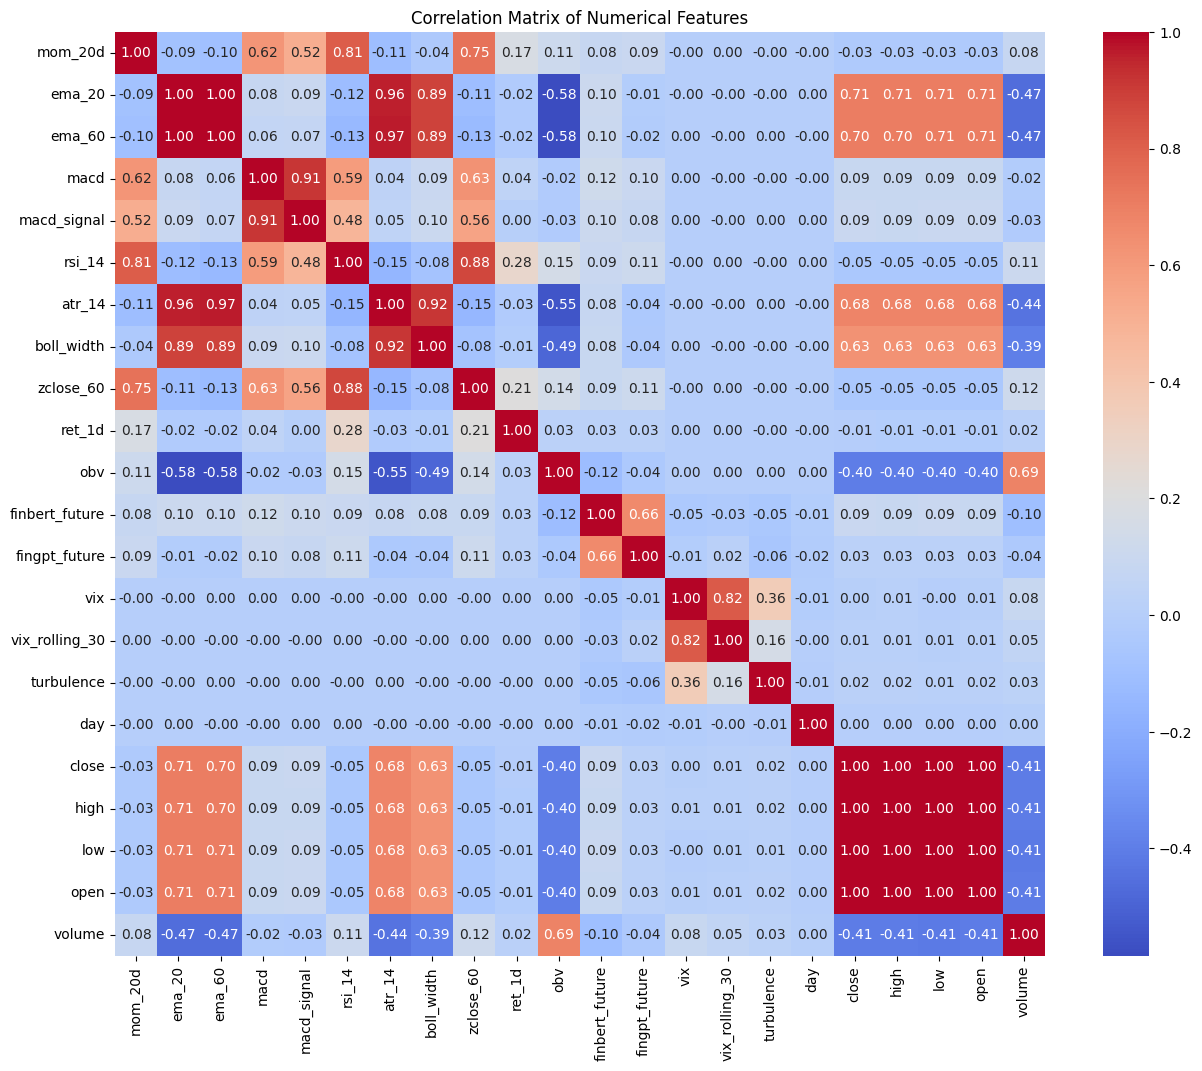

In [105]:
# Assuming your DataFrame is called df
# Select only numerical columns
numerical_cols = train_scaled.select_dtypes(include=['float64', 'int64']).columns
numerical_df = train_scaled[numerical_cols]

# Compute the correlation matrix
corr_matrix = numerical_df.corr()

# Plot the correlation matrix
plt.figure(figsize=(15, 12))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title("Correlation Matrix of Numerical Features")
plt.show()

In [106]:
n_repeat = 4

n_rows = len(train_scaled)
new_index = np.arange(n_rows // n_repeat + 1).repeat(n_repeat)[:n_rows]
train_scaled.index = new_index

n_rows = len(trade_scaled)
new_index = np.arange(n_rows // n_repeat + 1).repeat(n_repeat)[:n_rows]
trade_scaled.index = new_index

In [107]:
trade_scaled.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2668 entries, 0 to 666
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   mom_20d         2668 non-null   float64       
 1   ema_20          2668 non-null   float64       
 2   ema_60          2668 non-null   float64       
 3   macd            2668 non-null   float64       
 4   macd_signal     2668 non-null   float64       
 5   rsi_14          2668 non-null   float64       
 6   atr_14          2668 non-null   float64       
 7   boll_width      2668 non-null   float64       
 8   zclose_60       2668 non-null   float64       
 9   ret_1d          2668 non-null   float64       
 10  obv             2668 non-null   float64       
 11  finbert_future  2668 non-null   float64       
 12  fingpt_future   2668 non-null   float64       
 13  vix             2668 non-null   float64       
 14  vix_rolling_30  2668 non-null   float64       
 15  turbulence

In [108]:
train_scaled.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12852 entries, 0 to 3212
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   mom_20d         12852 non-null  float64       
 1   ema_20          12852 non-null  float64       
 2   ema_60          12852 non-null  float64       
 3   macd            12852 non-null  float64       
 4   macd_signal     12852 non-null  float64       
 5   rsi_14          12852 non-null  float64       
 6   atr_14          12852 non-null  float64       
 7   boll_width      12852 non-null  float64       
 8   zclose_60       12852 non-null  float64       
 9   ret_1d          12852 non-null  float64       
 10  obv             12852 non-null  float64       
 11  finbert_future  12852 non-null  float64       
 12  fingpt_future   12852 non-null  float64       
 13  vix             12852 non-null  float64       
 14  vix_rolling_30  12852 non-null  float64       
 15  turbulen

In [109]:
train_scaled

,mom_20d,ema_20,ema_60,macd,macd_signal,rsi_14,atr_14,boll_width,zclose_60,ret_1d,...,vix_rolling_30,turbulence,day,close,date,tic,high,low,open,volume
0,0.685507,-0.903761,-0.891396,-1.046426,-0.970341,0.699612,-0.940475,-0.923843,0.987336,1.428021,...,-0.230625,0.000000,1.0,7.080245,2010-03-30,AAPL,7.129179,7.032213,7.102760,527310000.0
0,1.021683,-0.005717,-0.042662,0.641083,0.406965,0.797606,0.060758,0.220503,0.659694,-0.323612,...,-0.436081,0.000000,1.0,57.688473,2010-03-30,BA,58.198436,57.037289,57.931683,4381300.0
0,-0.733192,1.395379,1.407072,1.042866,1.212849,-1.362424,1.368531,1.313582,-1.165287,-0.903036,...,-0.436081,0.000000,1.0,130.291199,2010-03-30,GS,132.876035,129.774224,132.480703,8184600.0
0,-0.973998,-0.485901,-0.473013,-0.637523,-0.649473,-0.134794,-0.488813,-0.610242,-0.481744,-0.201373,...,-0.436081,0.000000,1.0,29.849304,2010-03-30,JPM,30.163999,29.701999,30.063565,30296300.0
1,0.785951,-0.905085,-0.892294,-1.071166,-0.990576,0.815566,-0.955262,-1.003673,1.025395,0.084736,...,-0.195724,0.000000,2.0,7.054728,2010-03-31,AAPL,7.103061,7.038517,7.069438,430659600.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3211,0.215072,-0.735932,-0.746108,0.272826,0.120170,0.658766,-1.299920,-1.096863,0.528740,-0.460094,...,0.488828,2.349752,3.0,124.329124,2022-12-29,JPM,124.375790,123.479853,124.058471,6585200.0
3212,-0.878034,-0.622722,-0.524974,-0.692234,-0.745301,-0.894194,-0.225958,0.199250,-1.357444,-0.479064,...,0.476486,0.532299,4.0,128.123062,2022-12-30,AAPL,128.142788,125.657837,126.624212,77034200.0
3212,1.302316,-0.079880,-0.189747,1.279685,1.352814,1.008058,0.521951,-0.295671,0.915669,1.043908,...,0.476486,0.532299,4.0,190.490005,2022-12-30,BA,190.649994,187.039993,187.500000,4007400.0
3212,-0.682791,1.437352,1.460308,-0.889825,-0.767374,-0.824315,0.999328,1.245756,-0.111763,-1.154550,...,0.476486,0.532299,4.0,320.039093,2022-12-30,GS,320.328019,316.329619,318.510557,1031400.0


In [110]:
trade_scaled

,mom_20d,ema_20,ema_60,macd,macd_signal,rsi_14,atr_14,boll_width,zclose_60,ret_1d,...,vix_rolling_30,turbulence,day,close,date,tic,high,low,open,volume
0,-1.121864,-0.633504,-0.532115,-0.757143,-0.748580,-1.137085,-0.160049,0.353958,-1.393010,-1.425623,...,1.297599,8.368589,1.0,123.330635,2023-01-03,AAPL,129.079551,122.443150,128.468178,112117500.0
0,1.148400,-0.068815,-0.182392,1.278081,1.337887,1.009871,0.548340,-0.136675,0.882887,0.914773,...,1.297599,8.368589,1.0,195.389999,2023-01-03,BA,197.179993,192.399994,192.949997,8624600.0
0,-0.472749,1.434513,1.459144,-0.833860,-0.782530,-0.519106,0.945663,1.081406,-0.018727,0.267738,...,1.297599,8.368589,1.0,322.685974,2023-01-03,GS,324.904200,319.507763,322.014914,1589700.0
0,0.446213,-0.732194,-0.744637,0.312923,0.193223,0.646320,-1.333953,-1.298689,0.528850,0.243112,...,1.297599,8.368589,1.0,126.102341,2023-01-03,JPM,127.614235,124.954433,126.214342,11054800.0
1,-1.153314,-0.645043,-0.539688,-0.795502,-0.759263,-1.090375,-0.200869,0.331450,-1.340690,-0.358940,...,1.286911,2.751383,2.0,124.602699,2023-01-04,AAPL,126.870716,123.340502,125.125327,89113600.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
665,-0.964401,-0.311780,-0.300304,-0.694997,-0.783074,0.034600,-0.512357,-0.950393,-0.270208,0.348929,...,-0.424352,0.588618,3.0,301.070007,2025-08-28,JPM,301.239990,298.700012,300.019989,6410500.0
666,1.483820,-0.597075,-0.600454,-0.075288,0.055794,1.006524,-0.613650,0.386547,1.373899,0.189906,...,-0.434463,0.265210,4.0,232.139999,2025-08-29,AAPL,233.380005,231.369995,232.509995,39418400.0
666,-0.374238,-0.578342,-0.584540,-0.708901,-0.691956,-1.318933,-0.365161,-0.751985,-0.844869,-1.268908,...,-0.434463,0.265210,4.0,234.679993,2025-08-29,BA,238.050003,233.169998,236.130005,5008600.0
666,-0.408780,1.487214,1.485711,1.437158,1.394123,-0.158856,1.492166,1.235888,-0.624140,-0.081654,...,-0.434463,0.265210,4.0,745.250000,2025-08-29,GS,748.919983,738.900024,746.710022,1467000.0


In [111]:
def create_env(train, _ind, _hmax, _initial_amount, _reward_scaling, n_envs, randomize_episodes):
    stock_dimension = len(train.tic.unique())
    state_space = 1 + stock_dimension + len(_ind) * stock_dimension + 1
    print(f"Stock Dimension: {stock_dimension}, State Space: {state_space}")

    buy_cost_list = sell_cost_list = [0.001] * stock_dimension
    buy_cost_list = np.array(buy_cost_list)
    sell_cost_list = np.array(sell_cost_list)

    num_stock_shares = [0] * stock_dimension

    env_kwargs = {
        "hmax": _hmax,
        "initial_amount": _initial_amount,
        "num_stock_shares": num_stock_shares,
        "buy_cost_pct": buy_cost_list,
        "sell_cost_pct": sell_cost_list,
        "state_space": state_space,
        "stock_dim": stock_dimension,
        "tech_indicator_list": _ind,
        "action_space": stock_dimension,
        "reward_scaling": _reward_scaling,
        "model_name": "ppo",
        "mode": "rl",
        "randomize_episodes": randomize_episodes
    }


    def make_single_env():
        return StockTradingEnv(df=train, **env_kwargs)

    # if you want multiple parallel envs:
    if n_envs > 1:
        env_train = SubprocVecEnv([make_single_env for _ in range(n_envs)])
    else:
        env_train = DummyVecEnv([make_single_env])  # fallback to 1 env
    
    return env_train, env_kwargs

In [112]:
def run_wandb(env_kwargs, _name, algorithm, _total_timesteps, params, _reward, _notes=""):
    run = wandb.init(
        entity="influx_m",
        project="RL-DOW30-4SUB-final",
        name=_name,
        group=algorithm,
        job_type="train",
        tags=["rl", algorithm, "stock-trading"],
        notes=_notes,
        sync_tensorboard=True,
        config={  # <-- fixed comma here
            # Environment parameters
            "hmax": env_kwargs["hmax"],
            "initial_amount": env_kwargs["initial_amount"],
            "num_stock_shares": env_kwargs["num_stock_shares"],
            "buy_cost_pct": env_kwargs["buy_cost_pct"],
            "sell_cost_pct": env_kwargs["sell_cost_pct"],
            "state_space": env_kwargs["state_space"],
            "stock_dim": env_kwargs["stock_dim"],
            "tech_indicator_list": env_kwargs["tech_indicator_list"],
            "action_space": env_kwargs["action_space"],
            "reward_scaling": env_kwargs["reward_scaling"],
            "total_timesteps": _total_timesteps,
            "params_model": params,
            "reward": _reward
        },
        dir="./wandb_logs",
        mode="online",
    )

    return run

In [113]:
def run_model(algorithm, _total_timesteps, it, env_train):
    wandb_callback = WandbCallback(
        model_save_path="./models/",
        verbose=2,
        model_save_freq=10000,
    )

    tmp_path = f'./{algorithm}-{it}'

    agent = DRLAgent(env=env_train)
    model = agent.get_model(algorithm, tensorboard_log=tmp_path)

    new_logger = configure(tmp_path, ["stdout", "csv", "tensorboard"])
    model.set_logger(new_logger)

    trained = agent.train_model(
        model=model,
        tb_log_name=algorithm,
        total_timesteps=_total_timesteps,
        callbacks=[wandb_callback]
    )

    return trained, model

In [114]:
def backtest(trained, train, trade, _ind, _hmax, _initial_amount, _reward_scaling):
    stock_dimension = len(trade.tic.unique())
    state_space = 1 + stock_dimension + len(_ind) * stock_dimension + 1
    print(f"Stock Dimension: {stock_dimension}, State Space: {state_space}")

    buy_cost_list = sell_cost_list = [0.001] * stock_dimension
    buy_cost_list = np.array(buy_cost_list)
    sell_cost_list = np.array(sell_cost_list)

    num_stock_shares = [0] * stock_dimension

    env_kwargs = {
        "hmax": _hmax,
        "initial_amount": _initial_amount,
        "num_stock_shares": num_stock_shares,
        "buy_cost_pct": buy_cost_list,
        "sell_cost_pct": sell_cost_list,
        "state_space": state_space,
        "stock_dim": stock_dimension,
        "tech_indicator_list": _ind,
        "action_space": stock_dimension,
        "reward_scaling": _reward_scaling,
        "model_name": "ppo",
        "mode": "rl",
        "randomize_episodes": False
    }

    e_trade_gym = StockTradingEnv(df = trade, **env_kwargs)

    df_account_value, df_actions = DRLAgent.DRL_prediction(
        model=trained,
        environment = e_trade_gym)

    return e_trade_gym, df_account_value, df_actions

In [115]:
def analysis_backtest(trade, train, df_account_value):
    df_mvo, df_ew, df_bh, df_djia = build_benchmarks(trade, train)
    df_result, results = analysis_metrics_rl_benchmarks(df_account_value, df_mvo, df_ew, df_bh, df_djia)

    return df_result, results

In [ ]:
# Store all results here
all_results = {}

for rnd in [False, True]:
    for vec_env in [1, 3]:
        for i in range(1, 1 + 10):
            for algo in ALGORITHMS:
                print(f"\n=== Starting {algo.upper()} ===")
        
                # Step 1: Create environment kwargs for training
                env_train, env_kwargs = create_env(
                    train_scaled,
                    params["ind_train"],
                    params["hmax_train"],
                    params["initial_amount_train"],
                    params["reward_scaling_train"],
                    vec_env,
                    rnd
                )
                print("Step 1 done: Environment created")
        
                # Step 2: Initialize wandb run
                run = run_wandb(
                    env_kwargs,
                    f"init {algo} {i} {vec_env} {rnd}",
                    algo,
                    TOT_TIMESTEPS[algo][vec_env],
                    DEFAULT_PARAMS[algo],
                    _reward="simple return",
                    _notes=f"Training {algo} | num of env = {vec_env} | + {rnd} randomized episode"
                )
    
                print("Step 2 done: wandb run initialized")
        
                # Step 3: Train the model
                trained_model, model = run_model(algo, TOT_TIMESTEPS[algo][vec_env], i, env_train)
                print("Step 3 done: Model trained")
        
                """
                # Step 4: Backtest the trained model
                e_eval_gym, df_eval_value, df_eval_actions = backtest(
                    trained_model,
                    train,
                    valid,
                    params["ind_train"],
                    params["hmax_test"],
                    params["initial_amount_test"],
                    params["reward_scaling_test"],
                )
                print("Step 4 done: Backtest valid completed")
        
                """
        
                # Step 4: Backtest the trained model
                e_trade_gym, df_trade_value, df_trade_actions = backtest(
                    trained_model,
                    train_scaled,
                    trade_scaled,
                    params["ind_train"],
                    params["hmax_test"],
                    params["initial_amount_test"],
                    params["reward_scaling_test"],
                )
                print("Step 5 done: Backtest test completed")
    
                #df_res_valid, res_valid, valid_metrics = analysis_backtest(valid, train, df_eval_value, df_eval_actions)
                print("Step 6 done: Backtest valid analysis completed")
        
                df_res_trade, res_trade, trade_metrics = analysis_backtest(trade_scaled, train_scaled, df_trade_value, df_trade_actions)
                print("Step 7 done: Backtest test analysis completed")
        
                # Step 6: Log results to wandb
                run.log({"res_trade": res_trade['RL']})
                #run.log({"res_valid": res_valid['RL']})
                run.log({"trade_metrics": trade_metrics})
                #run.log({"valid_metrics": valid_metrics})
                print("Step 8 done: Results logged to wandb")

                # Step 7: Save results in dict for later use
                all_results[f"{i}-{algo}"] = {
                    #"df_res_valid": df_res_valid.to_dict(orient="records"),
                    #"res_valid": res_valid,
                    #"valid_metrics": valid_metrics,
                    "df_res_trade": df_res_trade.to_dict(orient="records"),
                    "res_trade": res_trade,
                    "trade_metrics": trade_metrics,
                }
        
                print(f"Step 8 done: Results saved for {algo.upper()}")